Data Generated: X shape (3, 36)

>>> Running: Basis=3, Alpha=1.0, Lambda=0.01 ...


Basis=3, Alpha=1.0:   0%|          | 0/5000 [00:00<?, ?it/s]


>>> Running: Basis=5, Alpha=0.1, Lambda=0.05 ...


Basis=5, Alpha=0.1:   0%|          | 0/5000 [00:00<?, ?it/s]


>>> Running: Basis=5, Alpha=1.0, Lambda=0.05 ...


Basis=5, Alpha=1.0:   0%|          | 0/5000 [00:00<?, ?it/s]

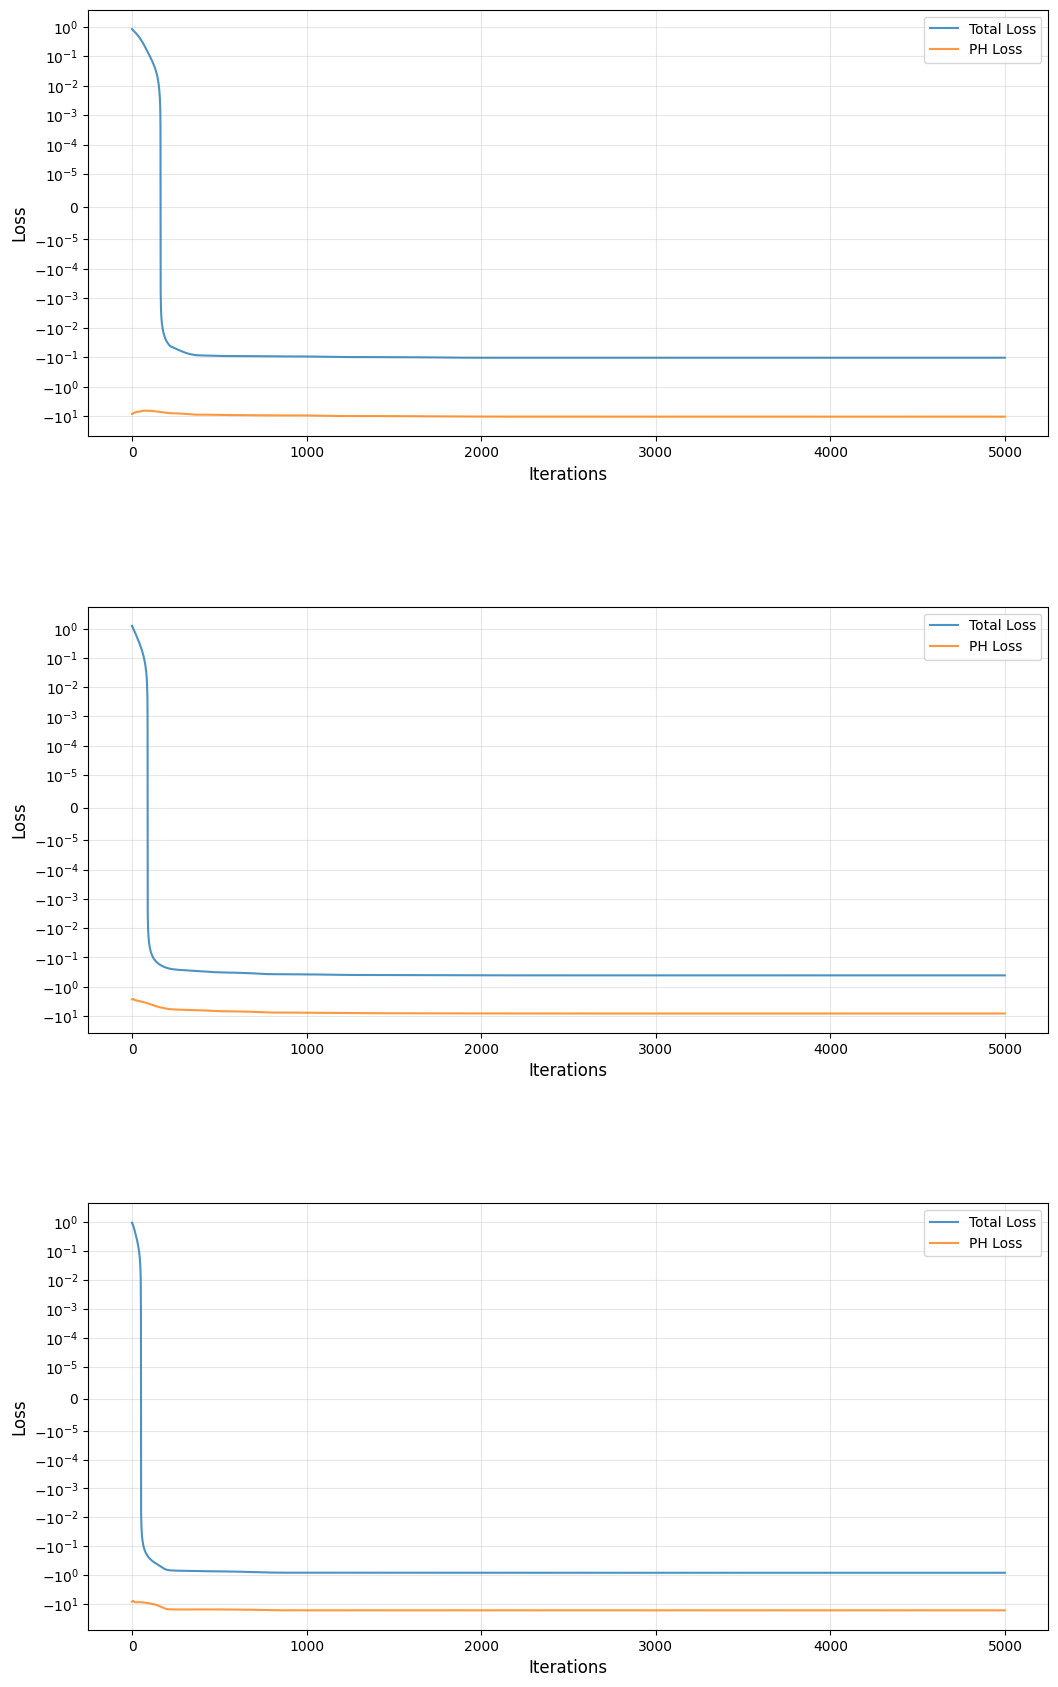

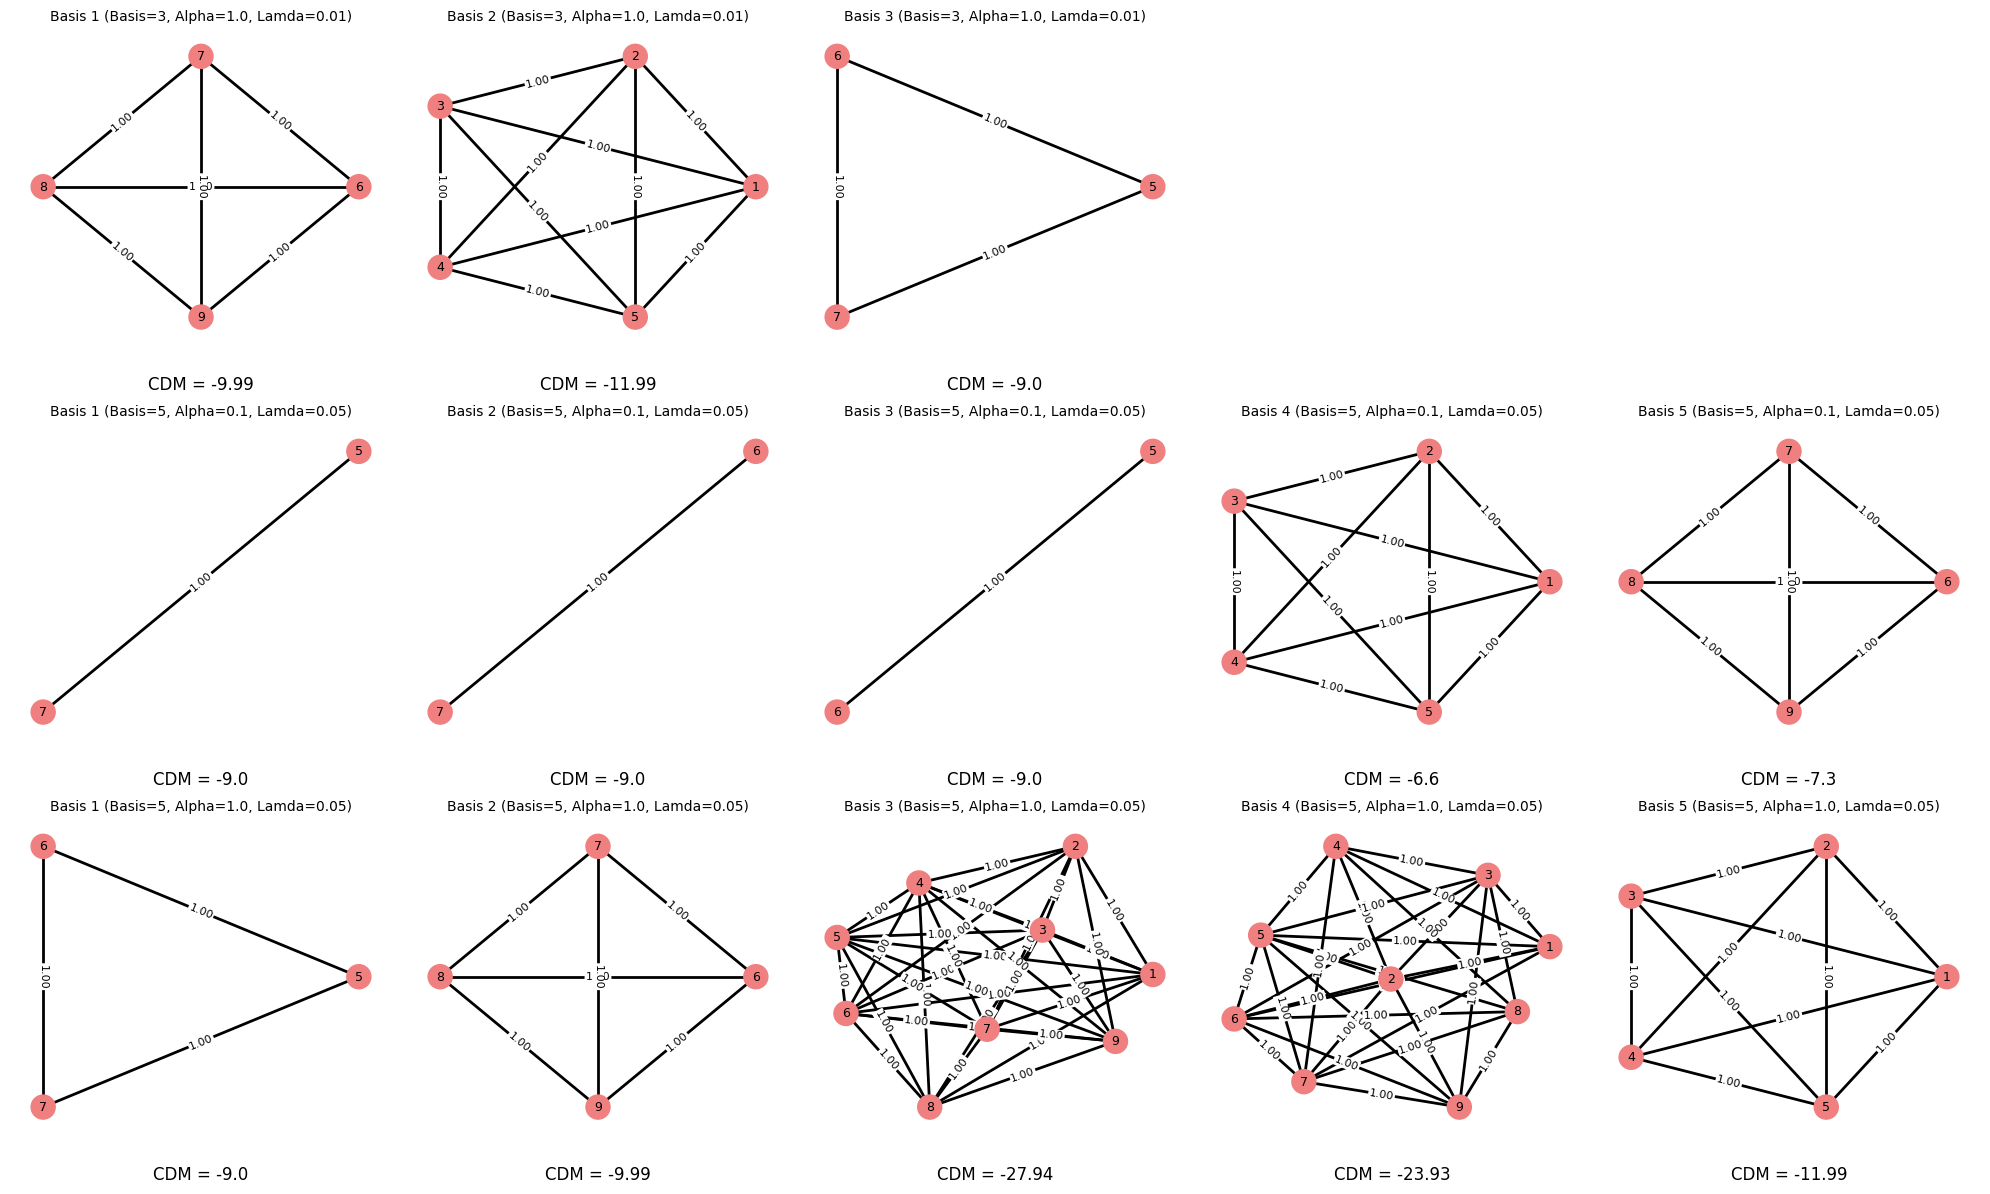

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import torch
import torch.optim as optim
from itertools import combinations
from tqdm.auto import tqdm
from graph_filtration import *


# ==========================================
# 1. Dataset Generation
# ==========================================
def generate_clique_dataset(
    cliques=[(1,2,3,4,5), (5,6,7), (6,7,8,9)],
    weights=[[2,1,2], [1,2,1], [1,1,2]]
):
    all_nodes = sorted(set(i for clique in cliques for i in clique))
    num_nodes = max(all_nodes)
    edge_list = [tuple(sorted(e)) for e in combinations(range(1, num_nodes + 1), 2)]
    edge_index = {e: i for i, e in enumerate(edge_list)}
    X = []

    for alpha in weights:
        row = np.zeros(len(edge_list))
        for coeff, clique in zip(alpha, cliques):
            for u, v in combinations(clique, 2):
                i = edge_index[tuple(sorted((u, v)))]
                row[i] += coeff
        X.append(row)

    return np.stack(X), edge_list, all_nodes

X, all_edges, nodes = generate_clique_dataset()
print(f"Data Generated: X shape {X.shape}")

# ==========================================
# 2. Experiment Setup
# ==========================================

device = 'cpu'
seed = 43
lr = 0.005
n_iterations = 5000
normalise = True
superlevel = True
PH_dims = [0, 1]
target_PH = [torch.tensor([[]], dtype=torch.float, device=device, requires_grad=False),
             torch.tensor([[]], dtype=torch.float, device=device, requires_grad=False)]
loss_fn = torch.nn.MSELoss()
epsilon = 1e-10

# Test setting list
experiment_configs = [
    {'n_comp': 3, 'alpha': 1.0},
    {'n_comp': 5, 'alpha': 0.1},
    {'n_comp': 5, 'alpha': 1.0}
]

# Ensure GraphFiltrationPH is defined
try:
    gpx = GraphFiltrationPH(max_dim=1, superlevel=superlevel)
except NameError:
    print("Error: 'GraphFiltrationPH' is not defined. Please run the import cell first.")
    raise

experiments_results = []

# ==========================================
# 3. Main Experiment Loop
# ==========================================
for config in experiment_configs:
    n_comp = config['n_comp']
    alpha_val = config['alpha']
    
    # Lambda Top Value setting
    if n_comp == 3:
        lambda_top_val = 0.01
    else:
        lambda_top_val = 0.05
    
    print(f"\n>>> Running: Basis={n_comp}, Alpha={alpha_val}, Lambda={lambda_top_val} ...")
    
    # Initialization
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    X_flat = X.reshape(X.shape[0], -1)
    X_tensor = torch.as_tensor(X_flat, dtype=torch.float, device=device)
    n_samples, n_features = X_flat.shape
    
    # Random Initialization
    W_init = np.random.rand(n_samples, n_comp)
    V_init = np.random.rand(n_comp, n_features)
    
    W = torch.tensor(W_init, dtype=torch.float, device=device, requires_grad=True)
    V = torch.tensor(V_init, dtype=torch.float, device=device, requires_grad=True)

    # Normalization
    if normalise:
        with torch.no_grad():
            normal_value = torch.max(V, dim=1).values.unsqueeze(1)
            V /= normal_value

    opt = optim.AdamW([W, V], lr=lr, weight_decay=0.0)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.9, patience=50000)
    
    # Loss history
    loss_history = []
    loss_ph_history = []
    
    # Training Loop
    for epoch in tqdm(range(n_iterations), desc=f"Basis={n_comp}, Alpha={alpha_val}", leave=False):
        
        # GD Update
        loss_PH = torch.tensor(0., device=device)
        
        # Topological Loss
        for j in range(n_comp):
            v_vec = V[j]
            diags = gpx(all_edges, v_vec)
            
            # Apply Alpha
            for dim in PH_dims:
                if dim == 0:
                    loss_PH -= pers_loss(diags[dim].diagram, target_PH[dim], remove_longest_D1=False)
                else:
                    loss_PH -= alpha_val * pers_loss(diags[dim].diagram, target_PH[dim], remove_longest_D1=False)

        loss_PH /= n_comp
        loss_apx = loss_fn(torch.mm(W, V), X_tensor)
        loss = loss_apx + lambda_top_val * loss_PH

        # Loss save
        loss_history.append(loss.item())
        loss_ph_history.append(loss_PH.item())

        opt.zero_grad()
        loss.backward()
        opt.step()
        scheduler.step(loss)

        # Constraints
        with torch.no_grad():
            W.clamp_(min=0)
            V.clamp_(min=0)
            if normalise:
                normal_value = torch.max(V, dim=1).values.unsqueeze(1)
                V /= (normal_value + epsilon)

    # CDM Calculation
    current_cdm_values = []
    with torch.no_grad():
        for i in range(n_comp):
            v_vec = V[i].detach()
            if not torch.is_tensor(v_vec):
                v_vec = torch.as_tensor(v_vec, dtype=torch.float64, device=device)
            
            diags = gpx(all_edges, v_vec)
            l_ph = 0.0
            for dim in PH_dims:
                if dim == 0:
                    l_ph -= pers_loss(diags[dim].diagram, target_PH[dim], remove_longest_D1=False).item()
                else:
                    l_ph -= alpha_val * pers_loss(diags[dim].diagram, target_PH[dim], remove_longest_D1=False).item()
            current_cdm_values.append(round(l_ph, 2))

    experiments_results.append({
        'n_comp': n_comp,
        'alpha': alpha_val,
        'lambda': lambda_top_val,
        'V': V.detach().cpu().numpy(),
        'CDM': current_cdm_values,
        'loss_history': loss_history,
        'loss_ph_history': loss_ph_history
    })

# ==========================================
# 4. Visualization 1: Combined Loss Curves (Symlog & Twinx)
# ==========================================
n_experiments = len(experiments_results)
fig_loss, axes_loss = plt.subplots(n_experiments, 1, figsize=(12, 6 * n_experiments))

if n_experiments == 1:
    axes_loss = [axes_loss]


plt.subplots_adjust(left=0.1, right=0.9, top=0.95, bottom=0.05, hspace=0.4)

for i, res in enumerate(experiments_results):
    n_c = res['n_comp']
    a_val = res['alpha']
    l_val = res['lambda']
    losses = res['loss_history']
    ph_losses = res['loss_ph_history']
    
    ax1 = axes_loss[i]
    

    l1, = ax1.plot(losses, label='Total Loss', linewidth=1.5, alpha=0.8)
    l2, = ax1.plot(ph_losses, label='PH Loss', linewidth=1.5, alpha=0.8)
    
    ax1.set_xlabel("Iterations", fontsize=12)
    ax1.set_ylabel("Loss", fontsize=12)
    ax1.set_yscale('symlog', linthresh=1e-5)
    ax1.grid(True, alpha=0.3)
    
    ax1.legend(handles=[l1, l2], loc='best')
plt.show()

# ==========================================
# 5. Visualization 2: Basis Graphs
# ==========================================
threshold = 0.1
def norm_edge(e): return tuple(sorted(e))

rows = len(experiments_results)
max_cols = 5 
fig, axes = plt.subplots(rows, max_cols, figsize=(4 * max_cols, 4 * rows))

for r, res in enumerate(experiments_results):
    n_c = res['n_comp']
    alpha_current = res['alpha']
    lambda_current = res['lambda']
    V_final = res['V']
    cdm_vals = res['CDM']
    
    for c in range(max_cols):
        ax = axes[r, c]
        
        if c >= n_c:
            ax.axis('off')
            continue
            
        weights = V_final[c]
        
        edge_weights = {}
        for idx, w in enumerate(weights):
            if w > threshold:
                e = norm_edge(all_edges[idx])
                edge_weights[e] = edge_weights.get(e, 0.0) + float(w)
        
        if not edge_weights:
            ax.set_title(f"Basis={n_c}, Alpha={alpha_current},  Lamda={lambda_current}\n#{c+1} [No edges]", fontsize=10)
            ax.axis('off')
            continue

        G = nx.Graph()
        G.add_edges_from(edge_weights.keys())
        pos = nx.kamada_kawai_layout(G)
        
        node_colors = ['lightcoral' for _ in G.nodes()]
        edge_widths = [edge_weights[norm_edge((u, v))] * 2 for u, v in G.edges()]
        
        nx.draw(
            G, pos, ax=ax,
            with_labels=True,
            node_color=node_colors,
            edge_color='black',
            edgelist=list(G.edges()),
            width=edge_widths,
            node_size=300,
            font_size=9
        )
        
        edge_labels = {(u, v): f"{edge_weights[norm_edge((u, v))]:.2f}" for u, v in G.edges()}
        nx.draw_networkx_edge_labels(
            G, pos, ax=ax,
            edge_labels=edge_labels,
            font_color='black',
            font_size=8,
            label_pos=0.5,
            rotate=True,
            bbox=dict(boxstyle='round,pad=0.1', fc='white', ec='none')
        )
        
        ax.set_title(f"Basis {c+1} (Basis={n_c}, Alpha={alpha_current}, Lamda={lambda_current})", fontsize=10)
        ax.text(
            0.5, -0.1, 
            f"CDM = {cdm_vals[c]}", 
            fontsize=12, 
            ha='center', va='top', 
            transform=ax.transAxes
        )
        ax.axis('off')

plt.tight_layout()
plt.show()